In [1]:
import geopandas as gpd
import yaml
import rasterio

from rasterio.mask import mask
from rasterio.plot import show
import matplotlib.pyplot as plt

from munch import munchify
import os
import numpy as np

In [2]:
# load config
with open("cafo_iowa/config.yaml", "r") as file:
    config = munchify(yaml.safe_load(file))

In [3]:
# load shape files
# naip
fp = os.path.join(config.naip_shp.output_path, "02_cropped_tiles.feather")
naip_shp = gpd.read_feather(fp)

# urban areas
urban_shp = gpd.read_file(config.urban_shp.input_path)

In [4]:
# set crs to be the same
urban_shp = urban_shp.to_crs(naip_shp.crs)

(4233, 50) (4239, 50)


<Axes: >

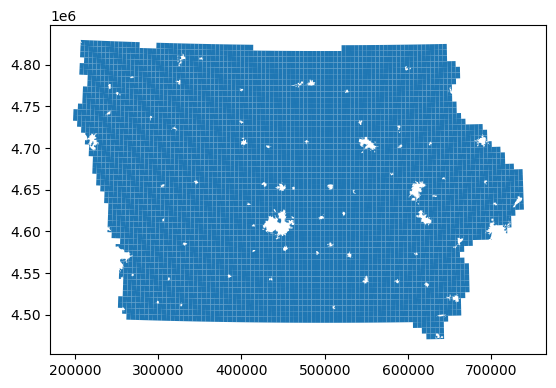

In [5]:
# mask urban areas from naip
naip_shp_nourban = naip_shp.copy()
naip_shp_nourban = gpd.overlay(naip_shp, urban_shp, how="difference")
print(naip_shp_nourban.shape, naip_shp.shape)
naip_shp_nourban.plot()

In [6]:
# select only naip tiles that intersect with urban areas
naip_shp_onlyurban = gpd.overlay(
    naip_shp, urban_shp, keep_geom_type=False, how="intersection"
)

<Axes: >

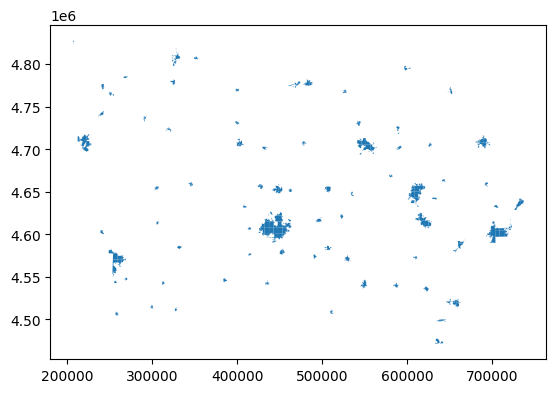

In [7]:
naip_shp_onlyurban.plot()

<Axes: >

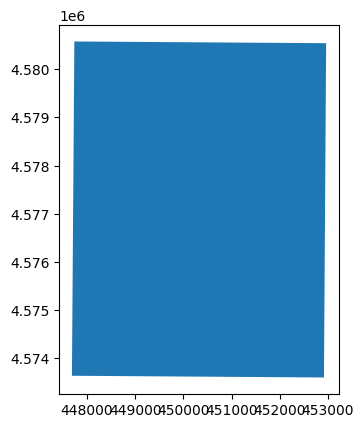

In [8]:
# plot naip tile
naip_shp[naip_shp["tile_id"] == "m_4109344_nw_15_060_20210818"].plot()

<Axes: >

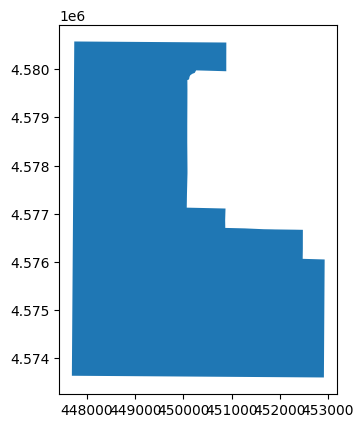

In [9]:
naip_shp_nourban[naip_shp_nourban["tile_id"] == "m_4109344_nw_15_060_20210818"].plot()

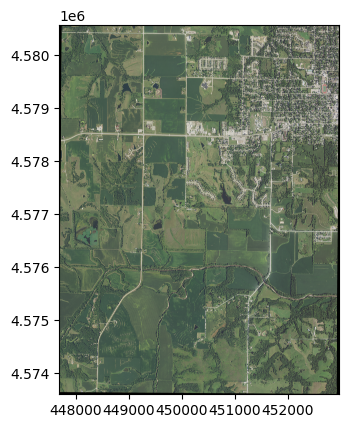

<Axes: >

In [10]:
# load image file
fp = os.path.join(config.naip.paths.cropped, "m_4109344_nw_15_060_20210818.tif")
img = rasterio.open(fp)
show(img)

In [28]:
def mask_urban_areas(img, urban_shp, invert=True):

    mask = urban_shp.geometry.values

    out_image, out_transform = rasterio.mask.mask(img, mask, invert=invert)
    out_meta = img.meta.copy()

    out_meta.update(
        {
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
        }
    )

    return out_image, out_meta

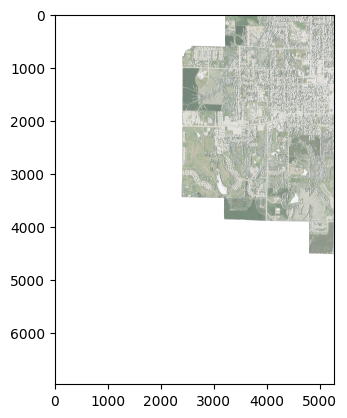

<Axes: >

In [16]:
# mask urban areas of image
img_nourban, _ = mask_urban_areas(fp, urban_shp, invert=False)
show(img_nourban)
# save masked image
fp = os.path.join(
    config.naip.paths.cropped, "m_4109344_nw_15_060_20210818_nourban2.tif"
)
with rasterio.open(fp, "w", **img.profile) as dst:
    dst.write(img_nourban)

In [18]:
geo = naip_shp[naip_shp["tile_id"] == "m_4109344_nw_15_060_20210818"]

In [30]:
with rasterio.open(fp, "r") as src:

    # make sure the crs is the same
    geo = geo.to_crs(src.crs)
    urban_shp = urban_shp.to_crs(src.crs)

    # crop the image according to polygon bounds
    poly = geo.geometry.values[0]
    out_img, out_transform = mask(src, shapes=[poly], crop=True)

    out_meta = src.meta.copy()
    out_meta.update(
        {
            "height": out_img.shape[1],
            "width": out_img.shape[2],
            "transform": out_transform,
        }
    )

    mask(out_img, [urban_shp.geometry.values], invert=True)
    # # mask out urban areas, if specified
    # out_img, out_transform = mask_urban_areas(out_img,
    #                                           urban_shp,
    #                                           invert=True)

    # save the cropped image to the out_path
    fp = os.path.join(
        config.naip.paths.cropped, "m_4109344_nw_15_060_20210818_nourban3.tif"
    )
    with rasterio.open(fp, "w", **img.profile) as dst:
        dst.write(img_nourban)

AttributeError: 'numpy.ndarray' object has no attribute 'nodata'